In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

# l2 regularization

In this notebook, we will implement a solver for Linear Regression with l2 regularization.

We will use the `make_regression` function from scikit-learn to generate a regression example.

This function, together with `make_classification`, are very useful for testing! You are invited to explore the documentation to see how you can use it.

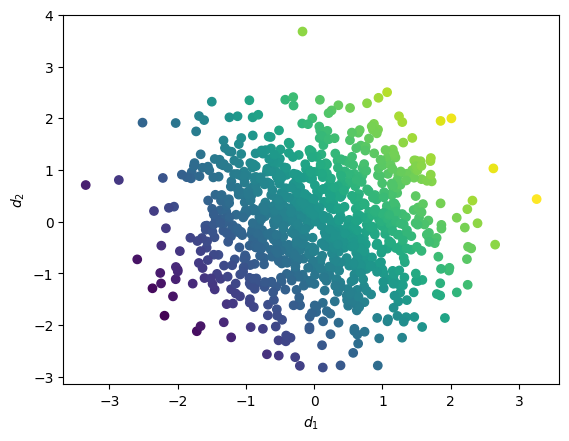

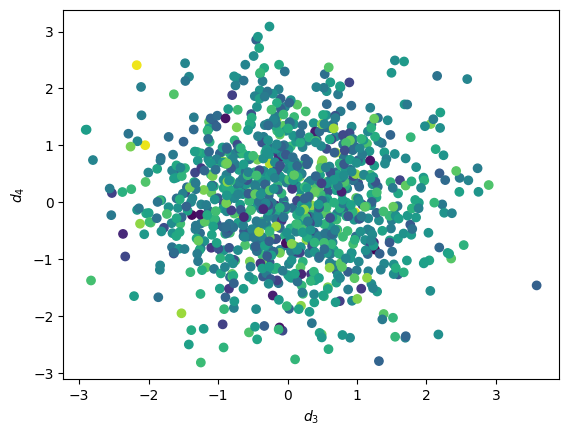

In [2]:
X,y = make_regression(
    n_samples=1000,
    n_features=50,
    n_informative=2,
    shuffle=False
)

plt.scatter(X[:,0], X[:,1], c=y)
plt.xlabel(r"$d_1$")
plt.ylabel(r"$d_2$")
plt.show()

plt.scatter(X[:,2], X[:,3], c=y)
plt.xlabel(r"$d_3$")
plt.ylabel(r"$d_4$")
plt.show()

You can start from the function for finding coefficients from last week, and add the necessary changes to include l2 regularization.

Die geschlossene Lösung der **L2-regularisierten linearen Regression (Ridge Regression)** lautet:


$$w(\alpha) = (X^\top X + \alpha I)^{-1} X^\top y$$




In [3]:
def find_coefficients_l2(X,y, alpha=1e-3):
    n_samples, n_features = X.shape
    I = np.eye(n_features)
    w = np.linalg.inv(X.T @ X + alpha * I) @ X.T @ y
    return w    

Then, you can solve the problem with different values of `alpha` and plot how this affects the coefficients found.

(50, 150)


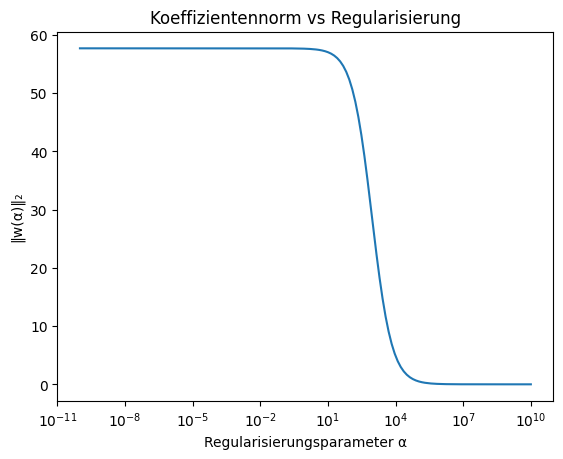

In [15]:
alphas = np.logspace(-10, 10, 150)
coeffs = [find_coefficients_l2(X, y, alpha) for alpha in alphas]
coeffs = np.array(coeffs).T
print(coeffs.shape)
plt.semilogx(alphas, np.linalg.norm(coeffs, axis=0))
plt.xlabel("Regularisierungsparameter α")
plt.ylabel("‖w(α)‖₂")
plt.title("Koeffizientennorm vs Regularisierung")
plt.show()


# note: plotting cell below assumes coeffs to be of size (n_dims, len(alphas))

In order to not have a crowded plot, we only plot one line every 10 coefficients below

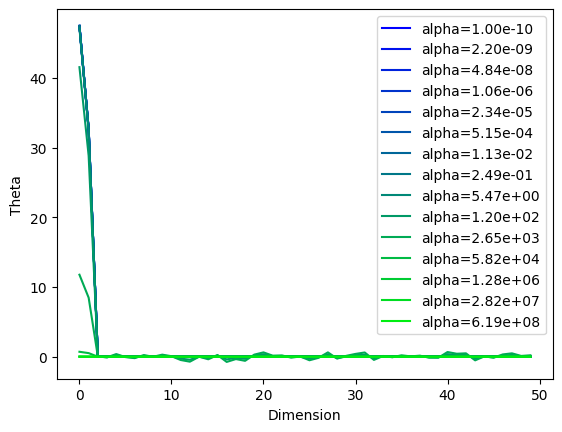

In [12]:
for i in range(0, alphas.size, 10):
    plt.plot(coeffs[:,i], color=[0., i/coeffs.shape[1], 1-(i/coeffs.shape[1])], label=f'alpha={alphas[i]:.2e}')

plt.legend()
plt.xlabel("Dimension")
plt.ylabel("Theta")
plt.show()

Je größer der Regularisierungfaktor $\alpha$, desto kleiner werden die Koeffizienten